<a href="https://colab.research.google.com/github/Anggardy/smartphone-analysis/blob/main/smartphone_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preparation

In [2]:
path = '/content/drive/MyDrive/Portfolio/Data Analyst/smartphone_price/smartphones.csv'

df=pd.read_csv(path)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 980 entries, 0 to 979
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   brand_name                 980 non-null    object 
 1   model                      980 non-null    object 
 2   price                      980 non-null    int64  
 3   avg_rating                 879 non-null    float64
 4   5G_or_not                  980 non-null    int64  
 5   processor_brand            960 non-null    object 
 6   num_cores                  974 non-null    float64
 7   processor_speed            938 non-null    float64
 8   battery_capacity           969 non-null    float64
 9   fast_charging_available    980 non-null    int64  
 10  fast_charging              769 non-null    float64
 11  ram_capacity               980 non-null    int64  
 12  internal_memory            980 non-null    int64  
 13  screen_size                980 non-null    float64

In [4]:
data_null = df.isna().sum()
data_null

,0
brand_name,0
model,0
price,0
avg_rating,101
5G_or_not,0
processor_brand,20
num_cores,6
processor_speed,42
battery_capacity,11
fast_charging_available,0


Langsung ambil data yang 5g dan punya harga antara range tertentu.

In [5]:
# Contoh: Mengambil data smartphone 5G dengan harga antara 20000 dan 50000
min_price = 20000
max_price = 50000
df_filtered = df[(df['5G_or_not'] == True) & (df['price'] >= min_price) & (df['price'] <= max_price)]
df_filtered.head()

,brand_name,model,price,avg_rating,5G_or_not,processor_brand,num_cores,processor_speed,battery_capacity,fast_charging_available,...,internal_memory,screen_size,refresh_rate,num_rear_cameras,os,primary_camera_rear,primary_camera_front,extended_memory_available,resolution_height,resolution_width
6,apple,Apple iPhone 12 Mini,40999,7.4,1,bionic,6.0,3.10,NaN,0,...,64,5.40,60,2,ios,12.0,12.0,0,2340,1080
7,apple,Apple iPhone 12 Mini (128GB),45999,7.5,1,bionic,6.0,3.10,NaN,0,...,128,5.40,60,2,ios,12.0,12.0,0,2340,1080
43,apple,Apple iPhone SE 3 2022,43900,NaN,1,bionic,6.0,3.22,NaN,0,...,64,4.70,60,1,ios,12.0,7.0,0,1334,750
44,apple,Apple iPhone SE 4,49990,6.0,1,bionic,6.0,3.22,NaN,0,...,64,6.10,60,1,ios,12.0,11.0,0,1580,750
46,asus,Asus ROG Phone 5s 5G,39999,8.7,1,snapdragon,8.0,2.90,6000.0,1,...,128,6.78,144,3,android,64.0,24.0,0,2448,1080


In [6]:
# Mengubah kolom '5G_or_not' menjadi tipe data boolean
df_filtered['5G_or_not'] = df_filtered['5G_or_not'].astype(bool)
df_filtered['fast_charging_available'] = df_filtered['fast_charging_available'].astype(bool)
df_filtered['extended_memory_available'] = df_filtered['extended_memory_available'].astype(bool)

/tmp/ipykernel_15408/2659830953.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['5G_or_not'] = df_filtered['5G_or_not'].astype(bool)
/tmp/ipykernel_15408/2659830953.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['fast_charging_available'] = df_filtered['fast_charging_available'].astype(bool)
/tmp/ipykernel_15408/2659830953.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead


## Data Kosong

In [7]:
data_null = df_filtered.isna().sum()
data_null

,0
brand_name,0
model,0
price,0
avg_rating,7
5G_or_not,0
processor_brand,2
num_cores,1
processor_speed,11
battery_capacity,4
fast_charging_available,0


In [8]:
df_filtered = df_filtered.dropna()

In [9]:
data_null = df_filtered.isna().sum()
data_null

,0
brand_name,0
model,0
price,0
avg_rating,0
5G_or_not,0
processor_brand,0
num_cores,0
processor_speed,0
battery_capacity,0
fast_charging_available,0


## Data Duplikat

In [10]:
data_dup = df_filtered.duplicated().sum()
data_dup

np.int64(0)

## Cek Deskripsi data

In [11]:
df_filtered.describe().round(2)

,price,avg_rating,num_cores,processor_speed,battery_capacity,fast_charging,ram_capacity,internal_memory,screen_size,refresh_rate,num_rear_cameras,primary_camera_rear,primary_camera_front,resolution_height,resolution_width
count,243.00,243.00,243.0,243.00,243.00,243.00,243.00,243.00,243.00,243.00,243.00,243.00,243.00,243.00,243.00
mean,31270.88,8.41,8.0,2.70,4820.98,65.51,8.13,163.03,6.59,113.06,3.03,66.63,22.93,2396.53,1123.52
std,7756.45,0.27,0.0,0.38,1176.52,35.91,1.92,61.05,0.14,20.96,0.44,30.57,10.75,277.66,219.15
min,20490.00,7.50,8.0,2.00,3700.00,10.00,4.00,64.00,6.00,60.00,2.00,12.00,8.00,1080.00,720.00
25%,24999.00,8.20,8.0,2.40,4500.00,33.00,8.00,128.00,6.50,90.00,3.00,50.00,16.00,2400.00,1080.00
50%,29990.00,8.40,8.0,2.84,4800.00,66.00,8.00,128.00,6.62,120.00,3.00,64.00,16.00,2400.00,1080.00
75%,35994.50,8.60,8.0,3.00,5000.00,80.00,8.00,256.00,6.67,120.00,3.00,64.00,32.00,2412.00,1080.00
max,49999.00,8.90,8.0,3.20,22000.00,240.00,16.00,512.00,6.92,165.00,4.00,200.00,60.00,3216.00,2400.00


In [12]:
cv = (df_filtered.std(numeric_only=True) / df_filtered.mean(numeric_only=True)).round(2)
print("Coefficient of Variance for each numerical column:")
cv[cv > 0.50]

Coefficient of Variance for each numerical column:


,0
fast_charging,0.55
extended_memory_available,1.42


## Cek Outlier

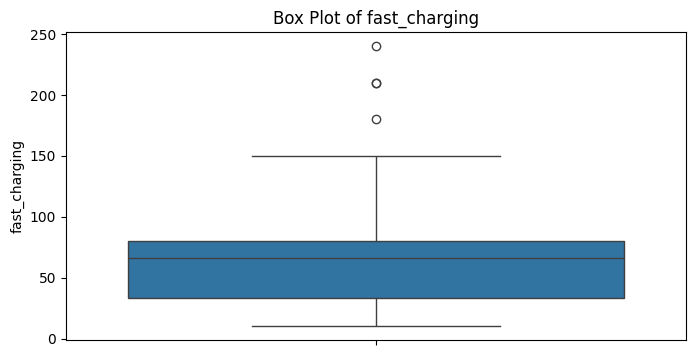

In [13]:
plt.figure(figsize=(8, 4))
sns.boxplot(y=df_filtered['fast_charging'])
plt.title('Box Plot of fast_charging')
plt.ylabel('fast_charging')
plt.show()

In [14]:
Q1 = df_filtered['fast_charging'].quantile(0.25)
Q3 = df_filtered['fast_charging'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out the outliers
df_filtered_no_outliers = df_filtered[(df_filtered['fast_charging'] >= lower_bound) & (df_filtered['fast_charging'] <= upper_bound)]

print(f"Jumlah baris sebelum menghapus outlier: {len(df_filtered)}")
print(f"Jumlah baris setelah menghapus outlier: {len(df_filtered_no_outliers)}")

# Anda bisa mengganti df_filtered dengan df_filtered_no_outliers untuk melanjutkan analisis dengan data tanpa outlier
df_filtered = df_filtered_no_outliers.copy()

Jumlah baris sebelum menghapus outlier: 243
Jumlah baris setelah menghapus outlier: 239


Data sudah bersih

# EDA

## Melihat Top Brand

Top 5 model berdasarkan rating

In [30]:
df_filtered.sort_values(by='avg_rating', ascending=False).head(10)

,brand_name,model,price,avg_rating,5G_or_not,processor_brand,num_cores,processor_speed,battery_capacity,fast_charging_available,...,internal_memory,screen_size,refresh_rate,num_rear_cameras,os,primary_camera_rear,primary_camera_front,extended_memory_available,resolution_height,resolution_width
207,motorola,Motorola Edge 30 Pro 5G,34999,8.9,True,snapdragon,8.0,3.00,4800.0,True,...,128,6.70,144,3,android,50.0,60.0,False,2400,1080
251,motorola,Motorola Moto X40,39999,8.9,True,snapdragon,8.0,3.20,4600.0,True,...,128,6.70,165,3,android,50.0,60.0,False,2400,1080
254,motorola,Motorola ThinkPhone,49990,8.9,True,snapdragon,8.0,3.20,5000.0,True,...,128,6.60,144,3,android,50.0,32.0,False,2400,1080
599,samsung,Samsung Galaxy A53 5G (8GB RAM + 128GB),33499,8.9,True,exynos,8.0,2.40,5000.0,True,...,128,6.50,120,4,android,64.0,32.0,True,2400,1080
597,samsung,Samsung Galaxy A53 (8GB RAM + 256GB),36499,8.9,True,exynos,8.0,2.40,5000.0,True,...,256,6.50,120,4,android,64.0,32.0,True,2400,1080
514,realme,Realme GT 2 Pro 5G (12GB RAM + 256GB),46999,8.9,True,snapdragon,8.0,3.00,5000.0,True,...,256,6.70,120,3,android,50.0,32.0,False,3216,1440
513,realme,Realme GT 2 Pro 5G,49959,8.9,True,snapdragon,8.0,3.00,5000.0,True,...,128,6.70,120,3,android,50.0,32.0,False,3216,1440
958,xiaomi,Xiaomi Redmi Note 12 Explorer,24999,8.9,True,dimensity,8.0,2.60,4300.0,True,...,256,6.67,120,3,android,200.0,16.0,True,2400,1080
855,xiaomi,Xiaomi 13 5G,46990,8.9,True,snapdragon,8.0,3.20,4500.0,True,...,128,6.36,120,3,android,50.0,32.0,False,2400,1080
708,tecno,Tecno Phantom X2 Pro,49999,8.9,True,dimensity,8.0,3.05,5160.0,True,...,256,6.80,120,3,android,50.0,32.0,False,2400,1080


Top 5 model berdasarkan brand

In [16]:
df_top_10 = df_filtered.groupby('brand_name').agg({
    'model' : 'count',
    'avg_rating' : lambda x: x.mean().round(2)
}).sort_values(by='model',ascending=False).head(10)

In [17]:
df_top_10_sort_rating = df_top_10[df_top_10['model'] > 10].sort_values(by='avg_rating', ascending=False)

/tmp/ipykernel_15408/1612513118.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_top_10_sort_rating.index, y='avg_rating', data=df_top_10_sort_rating, palette='viridis')


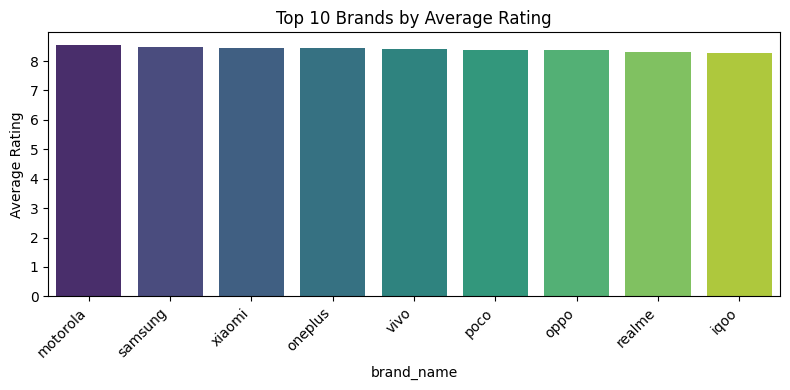

In [18]:
plt.figure(figsize=(8, 4))
sns.barplot(x=df_top_10_sort_rating.index, y='avg_rating', data=df_top_10_sort_rating, palette='viridis')
plt.title('Top 10 Brands by Average Rating')
plt.ylabel('Average Rating')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Pada tahap ini, dapat dilihat bahwa secara rating motorola dan samsung secara jumlah model dan rata-rata rating merupakan merk smartphone yang paling diminati. Hal ini dapat terlihat jika dibandingkan, motorola dengan 16 model memiliki rata-rata rating sebesar 8.55 sedangkan 8.49.

Namun secara jumlah model, Xiaomi paling unggul dengan memiliki 37 jenis model, disusul Oppo dengan 31 jenis model.

## Analisis Korelasi.

Korelasi per Kualitas vs Harga

In [19]:
corr_quality_vs_price = df_filtered['avg_rating'].corr(df_filtered['price'])
print(corr_quality_vs_price.round(2))

0.59


Korelasi keseluruhan

In [20]:
df_filtered[df_filtered.select_dtypes(include=['int64', 'float64']).columns].info()

<class 'pandas.core.frame.DataFrame'>
Index: 239 entries, 46 to 970
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   price                 239 non-null    int64  
 1   avg_rating            239 non-null    float64
 2   num_cores             239 non-null    float64
 3   processor_speed       239 non-null    float64
 4   battery_capacity      239 non-null    float64
 5   fast_charging         239 non-null    float64
 6   ram_capacity          239 non-null    int64  
 7   internal_memory       239 non-null    int64  
 8   screen_size           239 non-null    float64
 9   refresh_rate          239 non-null    int64  
 10  num_rear_cameras      239 non-null    int64  
 11  primary_camera_rear   239 non-null    float64
 12  primary_camera_front  239 non-null    float64
 13  resolution_height     239 non-null    int64  
 14  resolution_width      239 non-null    int64  
dtypes: float64(8), int64(7)
mem

In [21]:
corr_all = df_filtered.select_dtypes(include=['int64', 'float64']).corr().round(2)
corr_all

,price,avg_rating,num_cores,processor_speed,battery_capacity,fast_charging,ram_capacity,internal_memory,screen_size,refresh_rate,num_rear_cameras,primary_camera_rear,primary_camera_front,resolution_height,resolution_width
price,1.00,0.59,NaN,0.55,0.11,0.33,0.45,0.24,0.13,0.30,-0.05,-0.10,0.19,0.21,-0.02
avg_rating,0.59,1.00,NaN,0.37,0.08,0.22,0.47,0.34,0.18,0.30,0.10,0.21,0.41,0.22,-0.00
num_cores,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
processor_speed,0.55,0.37,NaN,1.00,0.02,0.47,0.27,0.02,0.35,0.42,-0.02,-0.07,0.08,0.18,0.09
battery_capacity,0.11,0.08,NaN,0.02,1.00,-0.04,0.09,0.10,0.16,0.10,0.02,0.15,-0.03,0.02,0.02
fast_charging,0.33,0.22,NaN,0.47,-0.04,1.00,0.28,0.14,0.37,0.33,-0.07,0.21,0.07,0.02,0.12
ram_capacity,0.45,0.47,NaN,0.27,0.09,0.28,1.00,0.64,0.13,0.09,-0.16,-0.04,0.25,0.11,-0.06
internal_memory,0.24,0.34,NaN,0.02,0.10,0.14,0.64,1.00,0.18,0.05,-0.15,0.08,0.17,0.04,-0.10
screen_size,0.13,0.18,NaN,0.35,0.16,0.37,0.13,0.18,1.00,0.50,-0.02,0.26,-0.07,0.06,0.14
refresh_rate,0.30,0.30,NaN,0.42,0.10,0.33,0.09,0.05,0.50,1.00,-0.10,0.17,-0.01,0.01,0.12


Disini terlihat pada num_cores hasilnya NaN. Hal ini karena semua nilainya 8.0

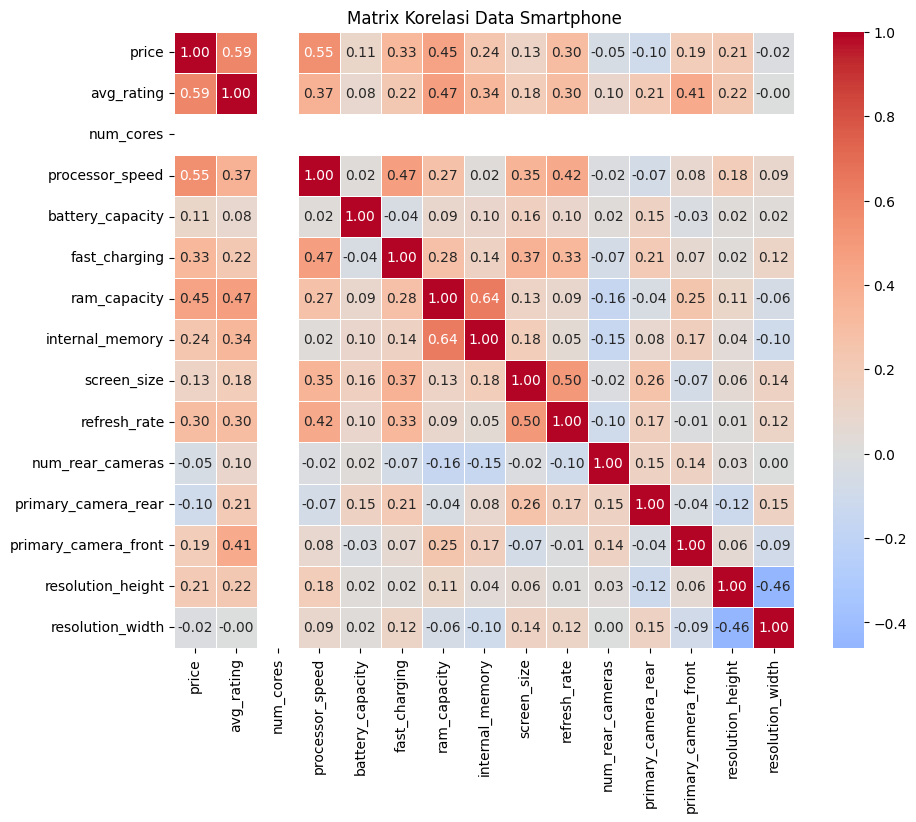

In [22]:
plt.figure(figsize=(10,8))
sns.heatmap(
    corr_all,
    annot=True,          # Menampilkan angka di dalam kotak
    fmt=".2f",           # Dua angka di belakang koma
    cmap='coolwarm',     # Warna: Merah (positif), Biru (negatif)
    linewidths=0.5,      # Memberi garis antar kotak
    center=0
)
plt.title('Matrix Korelasi Data Smartphone')
plt.show()

### Analisis p-value

In [23]:
from scipy.stats import pearsonr

# Hitung korelasi Pearson dan p-value
df_temp = df_filtered.dropna(subset=['avg_rating', 'price'])

# Hitung korelasi menggunakan data yang sudah bersih
corr_coeff, p_value = pearsonr(df_temp['avg_rating'], df_temp['price'])

print(f"Koefisien Korelasi Pearson antara avg_rating dan price: {corr_coeff:.2f}")
print(f"P-value: {p_value}")

# Interpretasi p-value
alpha = 0.05 # Tingkat signifikansi
if p_value < alpha:
    print(f"Karena p-value ({p_value:}) < alpha ({alpha}), kita dapat menolak hipotesis nol.")
    print("Ada hubungan linear yang signifikan secara statistik antara avg_rating dan price.")
else:
    print(f"Karena p-value ({p_value:}) >= alpha ({alpha}), kita gagal menolak hipotesis nol.")
    print("Tidak ada hubungan linear yang signifikan secara statistik antara avg_rating dan price pada tingkat signifikansi yang dipilih.")

Koefisien Korelasi Pearson antara avg_rating dan price: 0.59
P-value: 3.2804061392490863e-24
Karena p-value (3.2804061392490863e-24) < alpha (0.05), kita dapat menolak hipotesis nol.
Ada hubungan linear yang signifikan secara statistik antara avg_rating dan price.


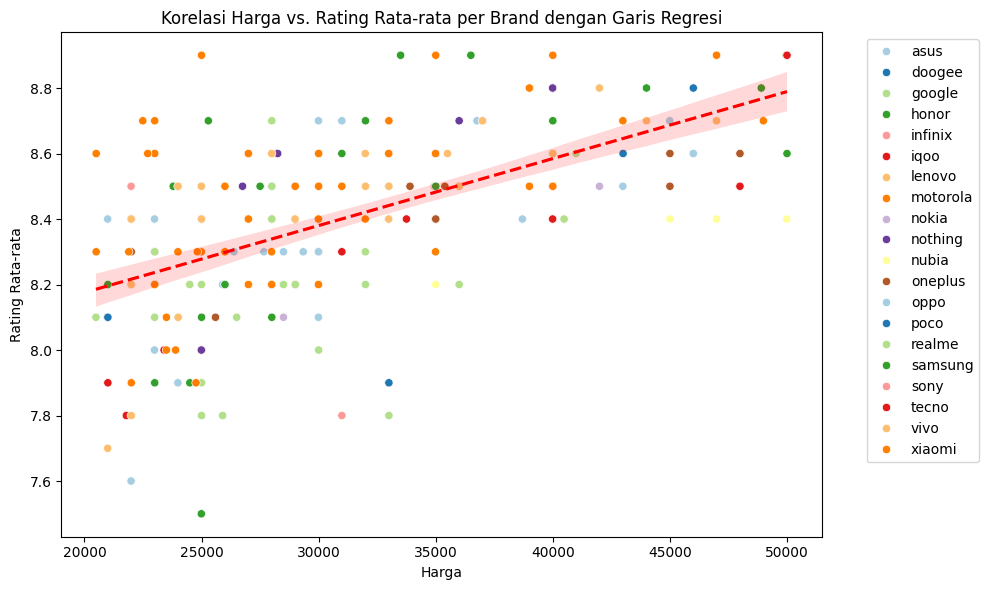

In [24]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='price', y='avg_rating', hue='brand_name', data=df_filtered, palette='Paired')
sns.regplot(x='price', y='avg_rating', data=df_filtered, scatter=False, color='red', line_kws={'linestyle':'--'})
plt.title('Korelasi Harga vs. Rating Rata-rata per Brand dengan Garis Regresi')
plt.xlabel('Harga')
plt.ylabel('Rating Rata-rata')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Secara teknis nilai korelasi tertinggi dipegang oleh hubungan antara kapasitas RAM dan Internal. Hal ini wajar karena biasanya semakin besar RAM maka semakin besar Penyimpanan internal yang ditawarkan.

Namun jika dilihat dari sisi rating dan harga, ini nilainya juga cukup berpengaruh. Hal ini bisa dilihat bahwa nilainya mencapai 0,59. Berdasarkan hal ini dapat disimpulkan bahwa semakin tinggi harganya bisa jadi ratingnya semakin tinggi, karena konsumen menganggap bahwa kualitasnya juga bisa semakin baik. Hal ini juga dibuktikan dengan adanya perbandingan nilai p-value yang mencapai 3.2804061392490863e-24 atau secara sederhana 0,001 < 0,05.

Bukti lain mungkin bisa dilihat pada korelasi antara avg_rating dan kecepatan prosesor yang mencapai 0,59. Hal ini cukup masuk akal dimana semakin cepat prosesornya maka pengguna lebih banyak yang suka. Ini juga menaikkan hubungan antara kecepatan prosesor dan harga yang mencapai 0,55.

## Analisis perbandingan rata-rata kapasitas ram dan baterai antar brand

In [25]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 239 entries, 46 to 970
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   brand_name                 239 non-null    object 
 1   model                      239 non-null    object 
 2   price                      239 non-null    int64  
 3   avg_rating                 239 non-null    float64
 4   5G_or_not                  239 non-null    bool   
 5   processor_brand            239 non-null    object 
 6   num_cores                  239 non-null    float64
 7   processor_speed            239 non-null    float64
 8   battery_capacity           239 non-null    float64
 9   fast_charging_available    239 non-null    bool   
 10  fast_charging              239 non-null    float64
 11  ram_capacity               239 non-null    int64  
 12  internal_memory            239 non-null    int64  
 13  screen_size                239 non-null    float64
 14

In [26]:
df_avg_specs = df_filtered.groupby('brand_name').agg({
    'ram_capacity' : lambda x: x.mean().round(2),
    'battery_capacity' : lambda x: x.mean().round(2),
    'internal_memory' : lambda x: x.mean().round(2)
}).sort_values(by='ram_capacity',ascending=False).head(10)

/tmp/ipykernel_15408/1128838014.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_avg_specs.index, y='ram_capacity', data=df_avg_specs, palette='viridis')


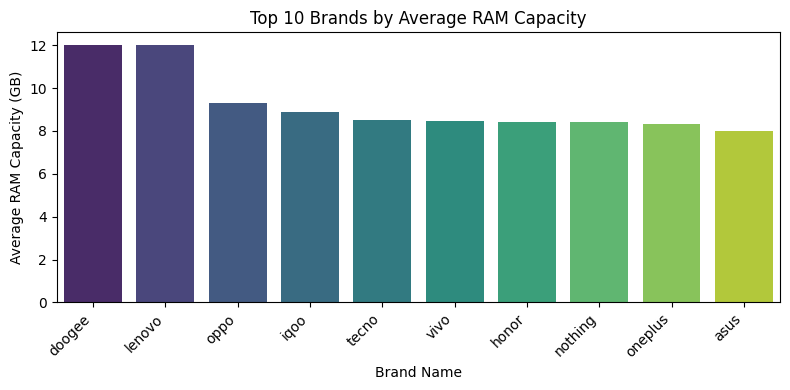

In [27]:
plt.figure(figsize=(8, 4))
sns.barplot(x=df_avg_specs.index, y='ram_capacity', data=df_avg_specs, palette='viridis')
plt.title('Top 10 Brands by Average RAM Capacity')
plt.xlabel('Brand Name')
plt.ylabel('Average RAM Capacity (GB)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_15408/356949234.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_avg_specs.index, y='battery_capacity', data=df_avg_specs, palette='viridis')


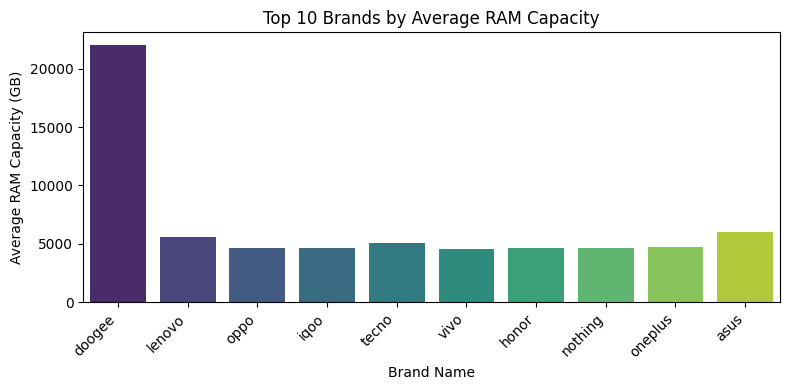

In [28]:
plt.figure(figsize=(8, 4))
sns.barplot(x=df_avg_specs.index, y='battery_capacity', data=df_avg_specs, palette='viridis')
plt.title('Top 10 Brands by Average RAM Capacity')
plt.xlabel('Brand Name')
plt.ylabel('Average RAM Capacity (GB)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_15408/2045575569.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_avg_specs.index, y='internal_memory', data=df_avg_specs, palette='viridis')


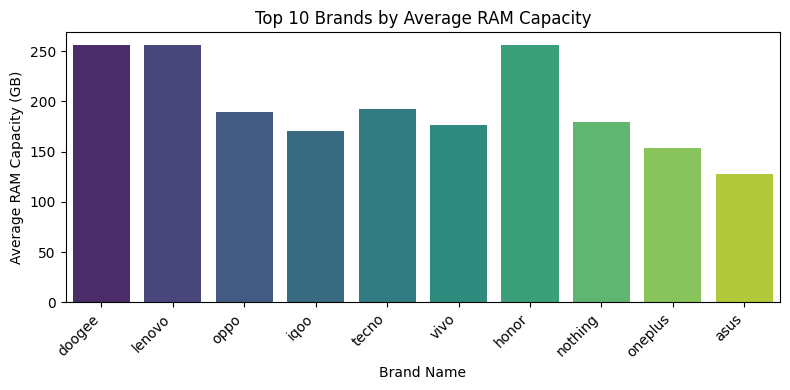

In [29]:
plt.figure(figsize=(8, 4))
sns.barplot(x=df_avg_specs.index, y='internal_memory', data=df_avg_specs, palette='viridis')
plt.title('Top 10 Brands by Average RAM Capacity')
plt.xlabel('Brand Name')
plt.ylabel('Average RAM Capacity (GB)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Berdasarkan data, brand Doogee benar-benar unggul di semua spesifikasi penyimpanan dan baterai.

# Rekomendasi (Insight)